# Conclusion final - NASA C-MAPSS RUL

Este notebook presenta el cierre del TP. No entrena modelos ni busca hiperparametros: solo carga los artefactos finales generados en `conclusion/` y muestra la seleccion final, las metricas oficiales, las metricas por rango de RUL y el ranking operativo de mantenimiento.

La idea es que funcione como una version presentable y reproducible de la conclusion escrita en `notas/resumen_final_tp.txt`.

## 1. Setup

Se cargan unicamente archivos finales ya consolidados. Esto mantiene separado el analisis de conclusion de las etapas de entrenamiento.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    pass

PROJECT_ROOT = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "conclusion" / "final_model_summary.csv").exists():
        PROJECT_ROOT = candidate
        break

assert PROJECT_ROOT is not None, f"No se encontro conclusion/final_model_summary.csv desde {Path.cwd()}"
CONCLUSION_DIR = PROJECT_ROOT / "conclusion"

model_summary = pd.read_csv(CONCLUSION_DIR / "final_model_summary.csv")
metric_summary = pd.read_csv(CONCLUSION_DIR / "final_metric_summary.csv")
rul_bin_metrics = pd.read_csv(CONCLUSION_DIR / "final_rul_bin_metrics.csv")
decision_summary = pd.read_csv(CONCLUSION_DIR / "maintenance_decision_summary.csv")
priority_ranking = pd.read_csv(CONCLUSION_DIR / "maintenance_priority_ranking.csv")

official_metrics = metric_summary.query("evaluation_scope == 'official_test_final_config'").copy()

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Modelos finales: {len(model_summary)} subsets")
print(f"Predicciones en ranking operativo: {len(priority_ranking)} casos")

Proyecto: C:\Users\frane\udesa\ML\vs\TPF-ML
Modelos finales: 4 subsets
Predicciones en ranking operativo: 707 casos


## 2. Criterio metodologico

- Los modelos se seleccionaron con validacion artificial sobre motores completos.
- El test oficial se uso solo para reporte final, no para buscar hiperparametros.
- Se entreno con RUL cappeado cuando correspondia, pero las metricas finales se calcularon contra RUL real.
- FD001/FD003 se trataron como problemas de una condicion operativa; FD002/FD004 incorporaron manejo explicito de condiciones.
- Los patrones latentes de falla se usaron para inspirar features, no como etiquetas supervisadas.

## 3. Modelos finales

In [2]:
display(
    model_summary[
        [
            "dataset",
            "final_model",
            "model_family",
            "feature_set",
            "window_size",
            "rul_cap",
            "sample_weight_scheme",
        ]
    ]
)

,dataset,final_model,model_family,feature_set,window_size,rul_cap,sample_weight_scheme
0,FD001,candidate_03_B_quantile_a040_search_14,LightGBM,temporal,50,125,none
1,FD002,xgb_condition_fault_sensitive_mid_guard,xgboost,condition_fault_sensitive,50,125,mid_rul_guard
2,FD003,fd003_lgbm_w50_cap125_quantile_a04_none_fault_...,LightGBM,fault_sensitive,50,125,none
3,FD004,fd004_xgb_fs_bin_weights_w70,xgboost,condition_fault_sensitive,70,125,bin_weights


Lectura rapida:

- FD001 y FD003 terminan con LightGBM quantile porque tienen una sola condicion operativa.
- FD002 y FD004 terminan con XGBoost porque en los subsets multi-condicion fue la familia mas fuerte.
- FD002 y FD004 usan features `condition_fault_sensitive`, que combinan normalizacion por condicion con senales temporales de degradacion.

## 4. Metricas oficiales finales

In [3]:
metric_cols = [
    "dataset",
    "model_name",
    "representation",
    "n",
    "mae",
    "rmse",
    "r2",
    "cmapss_score",
    "cmapss_score_mean",
    "dangerous_error_pct",
]

display(official_metrics[metric_cols].round(3))

,dataset,model_name,representation,n,mae,rmse,r2,cmapss_score,cmapss_score_mean,dangerous_error_pct
0,FD001,candidate_03_B_quantile_a040_search_14,temporal_w50,100,10.673,13.949,0.887,283.898,2.839,8.000
1,FD002,xgb_condition_fault_sensitive_mid_guard,temporal_w50_condition_fault_sensitive_mid_guard,259,16.619,25.280,0.779,5349.925,20.656,5.019
2,FD003,fd003_lgbm_w50_cap125_quantile_a04_none_fault_...,temporal_w50_fault_sensitive,100,10.820,14.555,0.876,394.763,3.948,9.000
3,FD004,fd004_xgb_fs_bin_weights_w70,temporal_w70_condition_fault_sensitive,248,17.909,26.071,0.771,4600.217,18.549,6.452


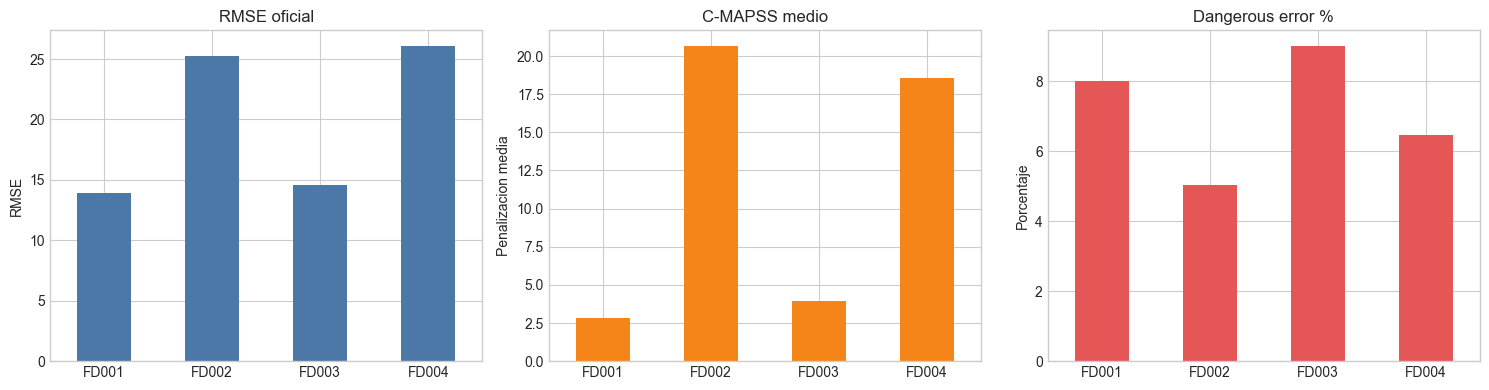

In [4]:
plot_df = official_metrics.set_index("dataset").sort_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_df["rmse"].plot(kind="bar", ax=axes[0], color="#4C78A8", title="RMSE oficial")
axes[0].set_xlabel("")
axes[0].set_ylabel("RMSE")

plot_df["cmapss_score_mean"].plot(kind="bar", ax=axes[1], color="#F58518", title="C-MAPSS medio")
axes[1].set_xlabel("")
axes[1].set_ylabel("Penalizacion media")

plot_df["dangerous_error_pct"].plot(kind="bar", ax=axes[2], color="#E45756", title="Dangerous error %")
axes[2].set_xlabel("")
axes[2].set_ylabel("Porcentaje")

for ax in axes:
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

Interpretacion central:

- FD001 y FD003 son los casos con menor error oficial y menor penalizacion media.
- FD002 y FD004 son mas dificiles por las multiples condiciones operativas; aun asi, el dangerous error final queda relativamente contenido.
- C-MAPSS se interpreta junto con dangerous error porque sobreestimar RUL es mas costoso que subestimarlo.

## 5. Metricas por rango de RUL

In [5]:
official_bins = rul_bin_metrics.query("evaluation_scope == 'official_test_final_config'").copy()
bin_order = ["0-30", "30-60", "60-90", "90+"]
official_bins["rul_bin"] = pd.Categorical(official_bins["rul_bin"], categories=bin_order, ordered=True)
official_bins = official_bins.sort_values(["dataset", "rul_bin"])

display(
    official_bins[
        [
            "dataset",
            "rul_bin",
            "n_eval",
            "mae",
            "rmse",
            "cmapss_score_mean",
            "dangerous_error_pct",
        ]
    ].round(3)
)

,dataset,rul_bin,n_eval,mae,rmse,cmapss_score_mean,dangerous_error_pct
3,FD001,0-30,25.0,3.730,4.938,0.507,0.000
2,FD001,30-60,14.0,8.099,9.384,1.440,7.143
1,FD001,60-90,13.0,18.424,21.267,8.882,38.462
0,FD001,90+,48.0,12.941,15.636,2.825,4.167
4,FD002,0-30,60.0,2.820,3.674,0.320,0.000
7,FD002,30-60,42.0,7.456,9.948,1.659,4.762
5,FD002,60-90,46.0,14.125,17.659,6.787,17.391
6,FD002,90+,111.0,28.578,36.293,44.584,2.703
9,FD003,0-30,20.0,2.514,3.262,0.272,0.000
8,FD003,30-60,21.0,11.512,15.738,7.155,9.524


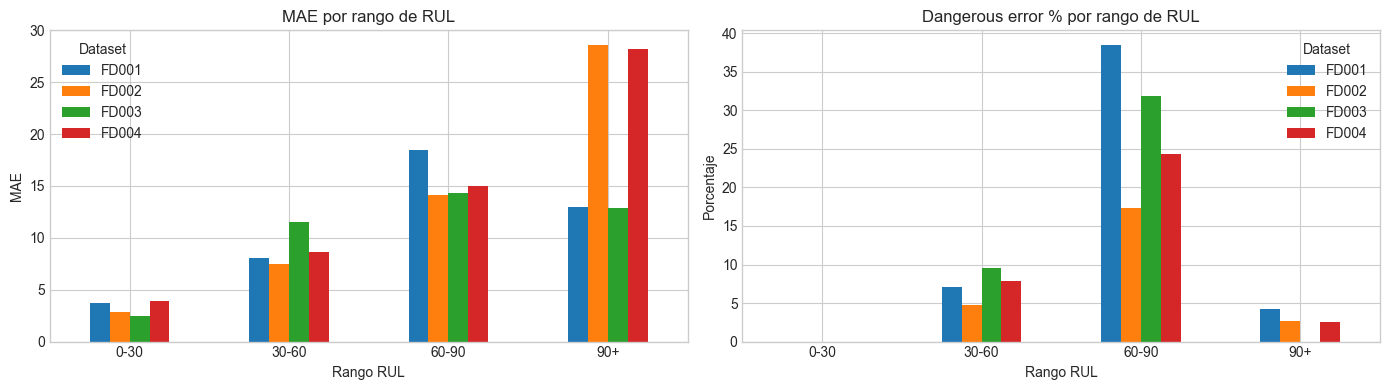

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

mae_by_bin = official_bins.pivot(index="rul_bin", columns="dataset", values="mae").reindex(bin_order)
danger_by_bin = official_bins.pivot(index="rul_bin", columns="dataset", values="dangerous_error_pct").reindex(bin_order)

mae_by_bin.plot(kind="bar", ax=axes[0], title="MAE por rango de RUL")
axes[0].set_xlabel("Rango RUL")
axes[0].set_ylabel("MAE")

danger_by_bin.plot(kind="bar", ax=axes[1], title="Dangerous error % por rango de RUL")
axes[1].set_xlabel("Rango RUL")
axes[1].set_ylabel("Porcentaje")

for ax in axes:
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Dataset")

plt.tight_layout()
plt.show()

La lectura por bins ayuda a distinguir error promedio de riesgo operativo. Un modelo puede tener RMSE aceptable y aun asi fallar de forma peligrosa en una banda intermedia de RUL. Por eso el TP reporta tambien `dangerous_error_pct` por rango.

## 6. Decision operativa de mantenimiento

In [7]:
decision_cols = ["urgent_replace", "schedule_soon", "monitor_close", "continue_monitoring"]
display(decision_summary[["dataset", "n_cases", *decision_cols, "dangerous_cases", "conservative_cases"]])

,dataset,n_cases,urgent_replace,schedule_soon,monitor_close,continue_monitoring,dangerous_cases,conservative_cases
0,FD001,100,22,16,13,49,8,10
1,FD002,259,61,37,47,114,13,63
2,FD003,100,21,17,16,46,9,6
3,FD004,248,55,30,39,124,16,66


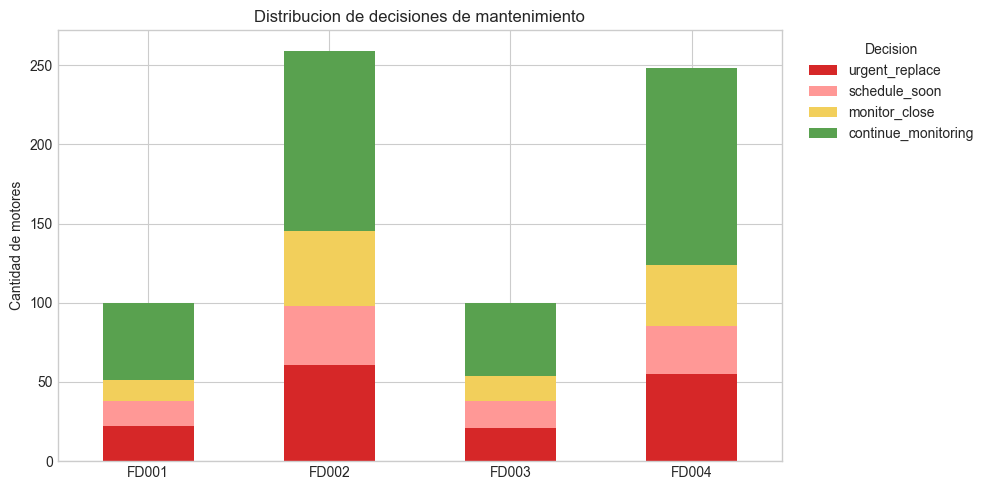

In [8]:
ax = decision_summary.set_index("dataset")[decision_cols].plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    color=["#D62728", "#FF9896", "#F2CF5B", "#59A14F"],
    title="Distribucion de decisiones de mantenimiento",
)
ax.set_xlabel("")
ax.set_ylabel("Cantidad de motores")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Decision", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Reglas usadas para el ranking operativo:

- `urgent_replace`: RUL predicho <= 30.
- `schedule_soon`: 30 < RUL predicho <= 60.
- `monitor_close`: 60 < RUL predicho <= 90.
- `continue_monitoring`: RUL predicho > 90.

## 7. Primeros motores priorizados

In [9]:
top_priority = priority_ranking.groupby("dataset", group_keys=False).head(5).copy()
display(
    top_priority[
        [
            "dataset",
            "priority_rank",
            "unit",
            "cycle",
            "y_true_rul_raw",
            "y_pred_rul",
            "abs_error",
            "maintenance_band",
            "risk_flag",
        ]
    ].round(3)
)

,dataset,priority_rank,unit,cycle,y_true_rul_raw,y_pred_rul,abs_error,maintenance_band,risk_flag
0,FD001,1,34,203,7.0,6.089,0.911,urgent_replace,within_20_cycles
1,FD001,2,76,205,10.0,7.587,2.413,urgent_replace,within_20_cycles
2,FD001,3,81,213,8.0,7.857,0.143,urgent_replace,within_20_cycles
3,FD001,4,82,162,9.0,8.862,0.138,urgent_replace,within_20_cycles
4,FD001,5,31,196,8.0,9.565,1.565,urgent_replace,within_20_cycles
100,FD002,1,116,171,7.0,4.051,2.949,urgent_replace,within_20_cycles
101,FD002,2,177,191,6.0,4.594,1.406,urgent_replace,within_20_cycles
102,FD002,3,138,200,7.0,5.449,1.551,urgent_replace,within_20_cycles
103,FD002,4,210,182,8.0,5.957,2.043,urgent_replace,within_20_cycles
104,FD002,5,11,162,6.0,6.247,0.247,urgent_replace,within_20_cycles


Este ranking no reemplaza una politica de mantenimiento real, pero muestra como traducir las predicciones de RUL a una priorizacion operativa simple y auditable.

## 8. Cierre por subset

In [10]:
model_by_dataset = model_summary.set_index("dataset")
metrics_by_dataset = official_metrics.set_index("dataset")

for dataset in ["FD001", "FD002", "FD003", "FD004"]:
    model = model_by_dataset.loc[dataset]
    metrics = metrics_by_dataset.loc[dataset]
    display(
        Markdown(
            f"**{dataset}**: modelo `{model['final_model']}` ({model['model_family']}), "
            f"feature_set `{model['feature_set']}`, window `{int(model['window_size'])}`. "
            f"RMSE oficial {metrics['rmse']:.3f}, C-MAPSS medio {metrics['cmapss_score_mean']:.3f}, "
            f"dangerous error {metrics['dangerous_error_pct']:.2f}%."
        )
    )

**FD001**: modelo `candidate_03_B_quantile_a040_search_14` (LightGBM), feature_set `temporal`, window `50`. RMSE oficial 13.949, C-MAPSS medio 2.839, dangerous error 8.00%.

**FD002**: modelo `xgb_condition_fault_sensitive_mid_guard` (xgboost), feature_set `condition_fault_sensitive`, window `50`. RMSE oficial 25.280, C-MAPSS medio 20.656, dangerous error 5.02%.

**FD003**: modelo `fd003_lgbm_w50_cap125_quantile_a04_none_fault_sensitive` (LightGBM), feature_set `fault_sensitive`, window `50`. RMSE oficial 14.555, C-MAPSS medio 3.948, dangerous error 9.00%.

**FD004**: modelo `fd004_xgb_fs_bin_weights_w70` (xgboost), feature_set `condition_fault_sensitive`, window `70`. RMSE oficial 26.071, C-MAPSS medio 18.549, dangerous error 6.45%.

## 9. Conclusion general

El resultado final confirma que la estructura del subset define la estrategia de modelado:

- En FD001, una representacion temporal robusta y un LightGBM quantile son suficientes para un modelo fuerte.
- En FD002, controlar condiciones operativas es indispensable; las features fault-sensitive mejoran la representacion de degradacion.
- En FD003, los patrones latentes de degradacion se capturan mejor con features temporales que con pseudo-clusters.
- En FD004, la mejor solucion combina las lecciones de FD002 y FD003: condicion operativa explicita y features de degradacion.

La entrega final queda respaldada por configs, metricas, predicciones, ranking de mantenimiento y notas explicativas.

## 10. Evaluacion post-calibracion controlada

Esta seccion incorpora los experimentos de calibracion hechos despues del cierre original. Se usan solo predicciones de validacion interna/artificial-cutoff sobre motores completos. El test oficial no se usa para elegir modelos ni calibraciones.

Los CSV `_v01` contienen las metricas detalladas de cada experimento. Los CSV `_v02` corrigen la marca de seleccion final en el resumen global sin sobrescribir los artefactos originales.

In [ ]:
POST_SUMMARY = pd.read_csv(PROJECT_ROOT / "results/final_calibration_summary_v02.csv")
POST_SELECTION = pd.read_csv(PROJECT_ROOT / "results/final_model_selection_after_calibration_v02.csv")

post_cols = [
    "dataset",
    "recommended_final_model_after_calibration",
    "changed_vs_previous",
    "CMAPSS_mean",
    "RMSE",
    "dangerous_20_pct",
    "bias",
    "reason_selected",
]
display(POST_SELECTION[post_cols])

Lectura del resultado post-calibracion:

- FD001 queda congelado y sin nuevos experimentos.
- FD002 conserva el modelo XGBoost condition/fault-sensitive previo: los ensambles y offsets no mejoraron de forma clara la penalizacion C-MAPSS.
- FD003 conserva offset 0: subir predicciones baja algo el RMSE, pero empeora C-MAPSS y errores tardios.
- FD004 cambia al ajuste `fd004_high_rul_thr120_off2`, porque mejora C-MAPSS y RMSE sin subir `dangerous_20_pct`.

## 11. Impacto por rango de RUL

Se revisa si la calibracion mueve el error donde mas importa para mantenimiento: RUL bajo y contribucion a penalizacion C-MAPSS.

In [ ]:
bin_files = {
    "FD002": "results/FD002/fd002_rul_bin_metrics_v01.csv",
    "FD003": "results/FD003/fd003_rul_bin_metrics_v01.csv",
    "FD004": "results/FD004/fd004_rul_bin_metrics_v01.csv",
}
post_bins = pd.concat(
    [pd.read_csv(PROJECT_ROOT / path) for path in bin_files.values()],
    ignore_index=True,
)
display(post_bins[["dataset", "candidate_name", "rul_bin", "n_motors", "MAE", "CMAPSS_mean", "CMAPSS_share", "dangerous_20_pct"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for dataset, group in post_bins.groupby("dataset"):
    axes[0].plot(group["rul_bin"], group["MAE"], marker="o", label=dataset)
    axes[1].plot(group["rul_bin"], group["CMAPSS_share"], marker="o", label=dataset)
axes[0].set_title("MAE por rango de RUL")
axes[0].set_xlabel("RUL bin")
axes[0].set_ylabel("MAE")
axes[1].set_title("Participacion en C-MAPSS")
axes[1].set_xlabel("RUL bin")
axes[1].set_ylabel("Share")
for ax in axes:
    ax.tick_params(axis="x", rotation=35)
    ax.legend()
plt.tight_layout()
plt.show()

## 12. Errores por condicion operativa

Para los subsets multi-condicion se carga la auditoria por condicion dominante en el ciclo de corte artificial. Esto verifica si la calibracion queda concentrada en una condicion o si hay un patron residual mas estructural.

In [ ]:
condition_files = {
    "FD002": "results/FD002/fd002_condition_error_analysis_v01.csv",
    "FD004": "results/FD004/fd004_condition_error_analysis_v01.csv",
}
post_conditions = pd.concat(
    [pd.read_csv(PROJECT_ROOT / path) for path in condition_files.values()],
    ignore_index=True,
)
display(post_conditions)

plot_conditions = post_conditions[pd.to_numeric(post_conditions.get("n_motors", 0), errors="coerce").fillna(0) > 0].copy()
if not plot_conditions.empty and "condition_dominant" in plot_conditions.columns:
    pivot = plot_conditions.pivot_table(index="condition_dominant", columns="dataset", values="CMAPSS_mean", aggfunc="mean")
    display(pivot)
    pivot.plot(kind="bar", figsize=(8, 4), title="CMAPSS medio por condicion dominante")
    plt.xlabel("condition_dominant")
    plt.ylabel("CMAPSS_mean")
    plt.tight_layout()
    plt.show()

## 13. Patrones residuales y clusters en FD004

El pedido incluia revisar si habia clusters residuales disponibles para FD004. En esta corrida no se encontro un CSV de etiquetas de cluster residual, por lo que se deja explicitado como diagnostico no ejecutado y no se inventan etiquetas nuevas.

In [ ]:
fd004_cluster = pd.read_csv(PROJECT_ROOT / "results/FD004/fd004_cluster_error_analysis_v01.csv")
display(fd004_cluster)

fd004_top10 = pd.read_csv(PROJECT_ROOT / "results/FD004/fd004_top10_cmapss_v01.csv")
display(fd004_top10)

## 14. Conclusion actualizada despues de calibracion

El cierre actualizado mantiene la logica original del TP: las decisiones se toman con validacion interna sobre motores completos y el test final queda reservado para reporte. FD002 no mejora con los ajustes probados, asi que se sostiene el modelo condition/fault-sensitive anterior. FD003 tampoco justifica calibracion positiva, porque las mejoras marginales de RMSE empeoran el costo asimetrico. FD004 si obtiene una mejora controlada con un offset pequeno solo en RUL alto, y pasa a ser el unico cambio recomendado post-calibracion.

La seleccion post-calibracion queda documentada en `results/final_model_selection_after_calibration_v02.csv`; los detalles por dataset quedan en los CSV `_v01` de cada subset y en las notas nuevas de `notas/FD002`, `notas/FD003` y `notas/FD004`.